# Distill two |+⟩ states with the [[6,2,2]] H6 code, then teleport each into its own surface code block

This notebook runs Quantinuum's Magic-H6 "0-level distillation" protocol
(arXiv:[2506.14688](https://arxiv.org/abs/2506.14688)) on a pair of states, and then
teleports each of the two distilled logical qubits into its own **rotated surface code
block**, where it would be consumed by a surface-code computation.

All circuits come from LightStim (`feat/h6-distillation-protocol` branch):
`lightstim.protocols.h6_distillation` for the distillation step and
`lightstim.protocols.h6_teleport` for distill + teleport. This notebook only runs and
analyses them.

**Clifford proxy.** The real protocol distills the non-Clifford `|H+⟩` magic state,
which Stim can't simulate. Following the paper's own Section III methodology, `|+⟩`
stands in for it. The `|+⟩` proxy measures the protocol's *circuit-level* fault
tolerance and how the error rate scales with the physical error rate `p`. It does
**not** measure the fidelity of a real magic state.

**Pipeline** (`build_h6_teleport_circuit`):

1. Encode `|++⟩_L` on the H6 code; reset surface blocks `S0`, `S1` to `|0⟩_L`.
2. One syndrome-extraction (SE) round on every patch.
3. **Distill:** the Bell-pair ancilla check of the logical Hadamard. Discard the shot on any nontrivial outcome.
4. **Teleport** (one-bit, XX variant), repeated `teleport_rounds = 2` times: an SE round
   on every patch, then for each slot `i` an ancilla measures
   `X_L(H6 slot i) ⊗ X_L(S_i)`.
5. Measure the H6 data in Z (completes the teleport).
6. `d` SE rounds on `S0`, `S1`, then read out `X_L` of each block. It should be `+1`.

Every detector on the H6 patch, the Bell check and the teleport ancillas is
**post-selected** (H6 has distance 2, so it can only detect errors, not correct them).
Only the surface blocks' own detectors are decoded (PyMatching).

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from lightstim.protocols.h6_distillation import build_h6_distillation_circuit
from lightstim.protocols.h6_teleport import (
    build_h6_teleport_circuit,
    build_surface_plus_baseline,
    inject_noise,
    run_simulation,
)


def fault_distance(circuit, p=1e-3):
    return len(inject_noise(circuit, p=p).shortest_graphlike_error())


def simulate(circuit, p, obs, max_shots=2_000_000, max_errors=300):
    # Post-selected logical error rate of observable(s) `obs`, and acceptance rate.
    st = run_simulation(inject_noise(circuit, p=p), max_shots=max_shots,
                        max_errors=max_errors, target_observable_indices=obs)
    return st.errors / st.post_selected_shots, st.post_selected_shots / st.shots

## 1. The distillation step on its own

The H6 encoder plus Bell-pair check, read out directly in X with no teleport. This is
the paper's level-1 protocol: circuit fault distance 2, so the post-selected logical
error rate scales as `p²`.

In [2]:
distill, _, _ = build_h6_distillation_circuit()
print(f"distillation circuit: {distill.num_qubits} qubits, {distill.num_detectors} detectors, "
      f"{distill.num_observables} observables, fault distance {fault_distance(distill)}")

ps_distill = np.array([1e-3, 2e-3, 4e-3, 8e-3])
ler_distill = np.array([simulate(distill, p, [0, 1], max_shots=20_000_000, max_errors=1000)[0]
                        for p in ps_distill])
slope = np.polyfit(np.log(ps_distill), np.log(ler_distill), 1)[0]
for p, l in zip(ps_distill, ler_distill):
    print(f"p={p:.0e}  post-selected LER (either slot) = {l:.2e}")
print(f"fitted slope: {slope:.2f}  (paper: 2.08)")

distillation circuit: 12 qubits, 8 detectors, 2 observables, fault distance 2


p=1e-03  post-selected LER (either slot) = 1.67e-05
p=2e-03  post-selected LER (either slot) = 7.66e-05
p=4e-03  post-selected LER (either slot) = 3.00e-04
p=8e-03  post-selected LER (either slot) = 1.18e-03
fitted slope: 2.04  (paper: 2.08)


## 2. Distill, then teleport into two surface code blocks

Build the full circuit at `d = 3` and check that it's clean without noise: no detector
fires, and both output blocks read `X_L = +1`. The random outcome of the joint XX
measurement is folded into each block's observable by LightStim's tracker, so the
observable reads +1 deterministically.

In [3]:
circuit, info, system = build_h6_teleport_circuit(d=3)
print(info)

det, obs = circuit.compile_detector_sampler().sample(4096, separate_observables=True)
print("noiseless: any detector fires:", det.any(), " any observable flips:", obs.any())

{'d': 3, 'rounds_post': 3, 'teleport_rounds': 2, 'check': True, 'num_qubits': 48, 'num_detectors': 114, 'num_observables': 2}
noiseless: any detector fires: False  any observable flips: False


## 3. Fault distance

The shortest set of physical faults that flips an output observable without tripping
any detector. The full protocol should be 2. Removing either safeguard should drop it
to 1:

- `check=False`: no Bell-pair check, i.e. teleport *undistilled* states.
- `teleport_rounds=1`: a single joint measurement, so one flipped outcome goes unnoticed.

In [4]:
for label, kwargs in [
    ("full protocol, d=3", dict(d=3)),
    ("full protocol, d=5", dict(d=5)),
    ("no Bell-pair check", dict(d=3, check=False)),
    ("single teleport round", dict(d=3, teleport_rounds=1)),
]:
    c, _, _ = build_h6_teleport_circuit(**kwargs)
    print(f"{label:24s} fault distance = {fault_distance(c)}")

full protocol, d=3       fault distance = 2


full protocol, d=5       fault distance = 2
no Bell-pair check       fault distance = 1
single teleport round    fault distance = 1


## 4. Logical error rate of each output block vs. physical error rate

For each `p`, sample the circuit with circuit-level depolarizing noise (LightStim's
`inject_noise`: `p` on two-qubit gates, measurement and reset; `m = p` on one-qubit
gates). Post-select, decode the surface blocks, and report the logical error rate of
each output block's `X_L` separately.

Two references at the same `d`:

- **no check**: the same teleport with the Bell-pair check removed. This is what
  distillation is buying you.
- **direct `|+⟩_L`**: `|+⟩_L` prepared transversally in a surface block, with no H6 at
  all. For the `|+⟩` proxy this is the best case. For a real magic state it doesn't
  exist (you can't prepare `|H+⟩_L` transversally), so read it as the cost of the
  surface block alone.

In [5]:
ps = np.array([5e-4, 1e-3, 2e-3, 4e-3])
results = {}
t0 = time.time()
for d in (3, 5):
    full, _, _ = build_h6_teleport_circuit(d=d)
    nocheck, _, _ = build_h6_teleport_circuit(d=d, check=False)
    direct, _, _ = build_surface_plus_baseline(d=d)
    for p in ps:
        ler0, acc = simulate(full, p, [0])
        ler1, _ = simulate(full, p, [1])
        ler_nc, acc_nc = simulate(nocheck, p, [0])
        ler_direct, _ = simulate(direct, p, [0])
        results[d, p] = dict(S0=ler0, S1=ler1, accept=acc, nocheck=ler_nc,
                             accept_nocheck=acc_nc, direct=ler_direct)
print(f"sampled in {time.time() - t0:.0f}s\n")

print(f"{'d':>2} {'p':>7} {'accept':>7} {'S0 LER':>9} {'S1 LER':>9} {'no-check':>9} {'direct':>9}")
for (d, p), r in results.items():
    print(f"{d:>2} {p:7.0e} {r['accept']:7.3f} {r['S0']:9.2e} {r['S1']:9.2e} "
          f"{r['nocheck']:9.2e} {r['direct']:9.2e}")

sampled in 23s

 d       p  accept    S0 LER    S1 LER  no-check    direct
 3   5e-04   0.930  2.08e-04  1.98e-04  7.26e-04  1.42e-04
 3   1e-03   0.864  7.31e-04  7.31e-04  1.88e-03  5.11e-04
 3   2e-03   0.748  2.90e-03  3.05e-03  5.29e-03  2.18e-03
 3   4e-03   0.558  1.14e-02  1.04e-02  1.60e-02  7.06e-03
 5   5e-04   0.925  9.46e-05  9.19e-05  6.52e-04  8.50e-06
 5   1e-03   0.856  4.56e-04  5.07e-04  1.53e-03  6.95e-05
 5   2e-03   0.733  2.24e-03  2.28e-03  4.25e-03  5.50e-04
 5   4e-03   0.538  1.16e-02  1.24e-02  1.63e-02  4.54e-03


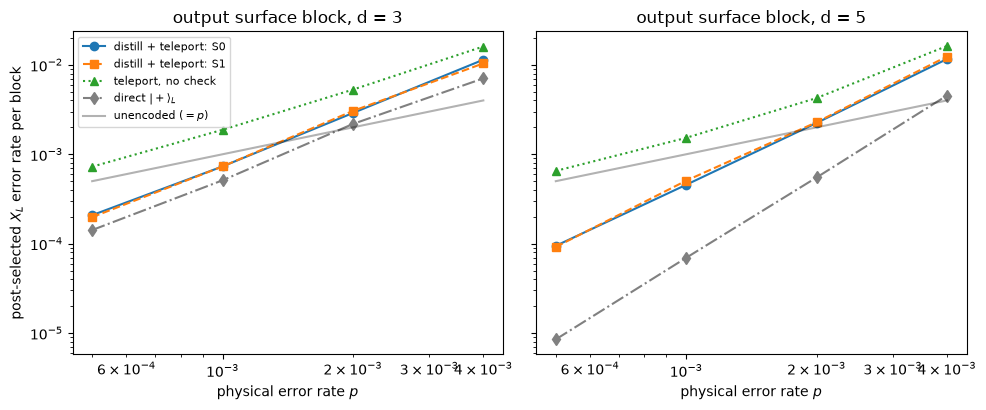

d=3  S0       fitted slope = 1.93
d=3  nocheck  fitted slope = 1.49
d=5  S0       fitted slope = 2.31
d=5  nocheck  fitted slope = 1.54


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, d in zip(axes, (3, 5)):
    get = lambda key: np.array([results[d, p][key] for p in ps])
    ax.loglog(ps, get("S0"), "o-", label="distill + teleport: S0")
    ax.loglog(ps, get("S1"), "s--", label="distill + teleport: S1")
    ax.loglog(ps, get("nocheck"), "^:", label="teleport, no check")
    ax.loglog(ps, get("direct"), "d-.", color="gray", label=r"direct $|+\rangle_L$")
    ax.loglog(ps, ps, "k-", alpha=0.3, label="unencoded ($= p$)")
    ax.set_title(f"output surface block, d = {d}")
    ax.set_xlabel("physical error rate $p$")
axes[0].set_ylabel(r"post-selected $X_L$ error rate per block")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

for d in (3, 5):
    for key in ("S0", "nocheck"):
        y = np.array([results[d, p][key] for p in ps])
        print(f"d={d}  {key:8s} fitted slope = {np.polyfit(np.log(ps), np.log(y), 1)[0]:.2f}")

## 5. Acceptance rate

The fraction of shots kept after post-selection on every H6, Bell-check and teleport
detector. The rest are discarded and retried, which is the time cost of distillation.

In [7]:
for d in (3, 5):
    acc = [results[d, p]["accept"] for p in ps]
    acc_nc = [results[d, p]["accept_nocheck"] for p in ps]
    print(f"d={d}: " + "  ".join(f"p={p:.0e}: {a:.3f} (no check {b:.3f})"
                                 for p, a, b in zip(ps, acc, acc_nc)))

d=3: p=5e-04: 0.930 (no check 0.935)  p=1e-03: 0.864 (no check 0.876)  p=2e-03: 0.748 (no check 0.767)  p=4e-03: 0.558 (no check 0.589)
d=5: p=5e-04: 0.925 (no check 0.930)  p=1e-03: 0.856 (no check 0.866)  p=2e-03: 0.733 (no check 0.752)  p=4e-03: 0.538 (no check 0.564)


## 6. What limits the output: the teleport, not the distillation

Distillation alone reaches ~1e-5 at `p = 1e-3` (section 1). The teleported blocks sit
well above that, even at `d = 5`. The dominant failures are pairs of faults that flip
*both* repeats of a joint XX measurement the same way, which the repeat-consistency
check can't see. Repeating the joint measurement more times pushes that failure to
higher order, at the cost of a lower acceptance rate (more detectors to post-select on).

In [8]:
print(f"{'teleport_rounds':>15} {'p':>7} {'S0 LER':>9} {'accept':>7}")
for tr in (2, 3, 5):
    c, _, _ = build_h6_teleport_circuit(d=5, teleport_rounds=tr)
    for p in (1e-3, 2e-3):
        ler, acc = simulate(c, p, [0])
        print(f"{tr:>15} {p:7.0e} {ler:9.2e} {acc:7.3f}")

teleport_rounds       p    S0 LER  accept


              2   1e-03  4.78e-04   0.856


              2   2e-03  2.28e-03   0.733


              3   1e-03  1.81e-04   0.805


              3   2e-03  1.10e-03   0.649


              5   1e-03  8.62e-05   0.714


              5   2e-03  6.88e-04   0.509


## Summary

All numbers are at `p = 1e-3`, with `m = p`, and are approximate (Monte Carlo).

- **Distillation alone** (section 1) is fault distance 2. Its post-selected error
  scales as `p²` (≈2.0, paper: 2.08), at ≈2e-5 for either slot.
- **Distill + teleport** (sections 2–4) is still fault distance 2, and each output
  surface block's `X_L` error scales as `p²` (slope ≈1.9–2.0 at `d = 3`, ≈2.2–2.3 at `d = 5`).
  Per block it is ≈7e-4 at `d = 3` and ≈4.5e-4 at `d = 5`. Both blocks behave the same.
- **Distillation pays off.** Removing the Bell-pair check drops the fault distance to 1.
  The error then scales as ≈`p^1.5`: ≈1.8e-3 per block, 2.5–4× worse than with the check.
- **Acceptance** is ≈86% at `d = 3` and ≈85% at `d = 5`. The Bell-pair check itself
  costs only ~1% of that; most discards come from the H6 and teleport detectors.
- **The teleport is the bottleneck, not the distillation** (section 6). Repeating the
  joint XX measurement 5× instead of 2× cuts the `d = 5` per-block error from ≈4.5e-4
  to ≈8e-5, while acceptance drops from ≈86% to ≈71%.
- The direct `|+⟩_L` reference is still lower at `d = 5` (≈7e-5). That's expected:
  the proxy state is free to prepare in the surface code, which a real `|H+⟩` isn't.

**Caveats**

- This is the `|+⟩` Clifford proxy. It tests circuit-level fault tolerance and
  scaling, not the fidelity of a real `|H+⟩` magic state.
- The joint XX measurement uses one bare ancilla over a weight-`3 + d` operator, with
  no flag. Under the proxy that's safe: the ancilla's hook faults are X errors, which
  `X_L` can't see. For a real magic state those hooks would matter, and the gadget would
  need flags or a lattice-surgery-style merge.
- The noise model is LightStim's uniform circuit-level depolarizing noise, not the
  paper's hardware-calibrated one.